          Regione  2025  2024  2023  2022  2021
0         Abruzzo  1326  1302  1008   832   610
1      Basilicata   373   364   287   259   188
2        Calabria  1077  1035   774   652   493
3        Campania  4473  4130  3396  1184   776
4  Emilia-Romagna  5282  5086  4050  3460  2392
(20, 6)


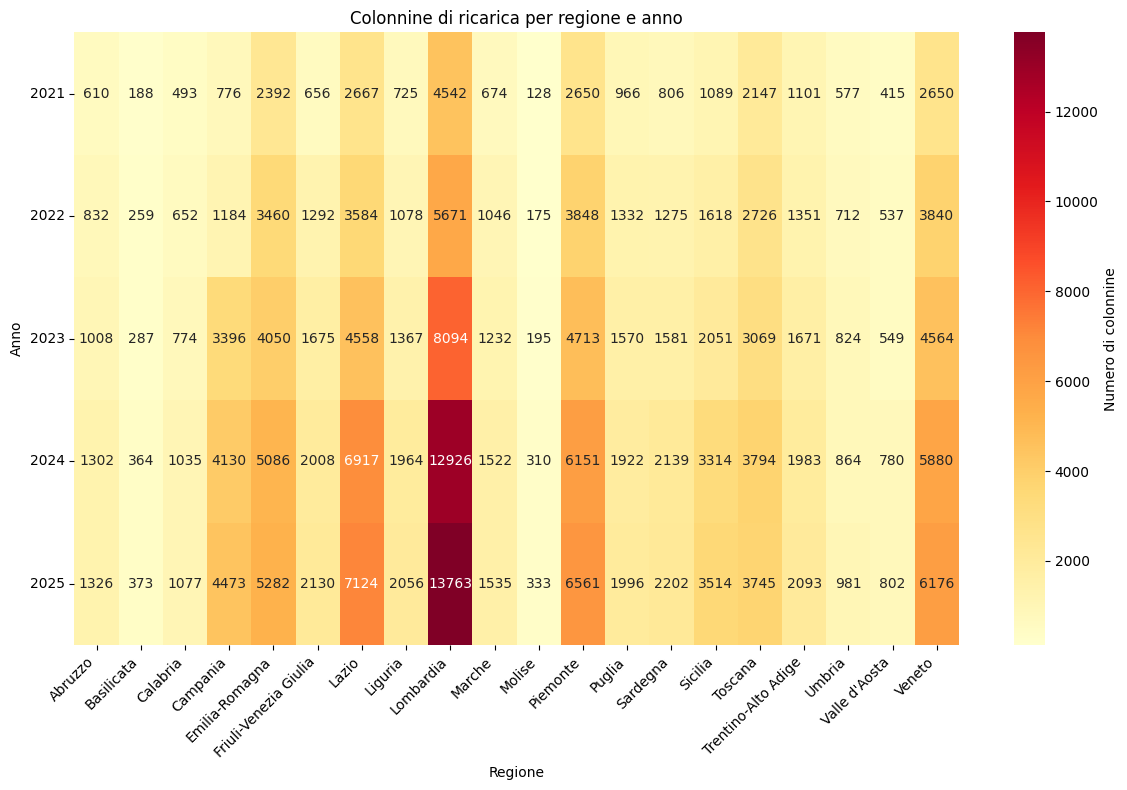

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/csv/colonne_ricarica_per_regione.csv', sep=';')

print(df.head())
print(df.shape)

# Trasponi per heatmap
df_heatmap = df.set_index('Regione')[['2021', '2022', '2023', '2024', '2025']].T 

df_heatmap.to_csv('colonne_ricarica_per_regione_trasp.csv')

# Heatmap principale
plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Numero di colonnine'})
plt.title('Colonnine di ricarica per regione e anno')
plt.xlabel('Regione')
plt.ylabel('Anno')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.close()

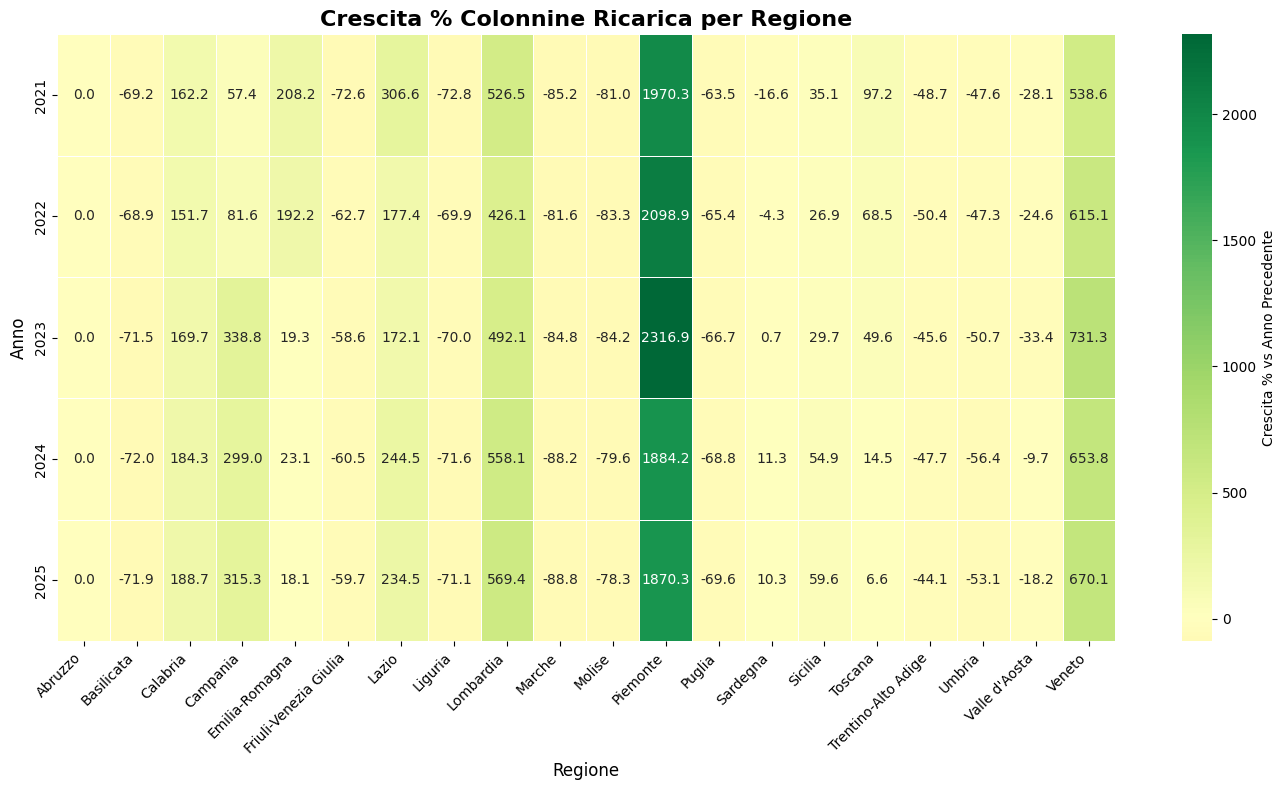

In [ ]:
# HEATMAP % CRESCITA ANNO SU ANNO
df_pct = df_heatmap.pct_change(axis=1) * 100  # Crescita orizzontale
df_pct = df_pct.fillna(0).round(1)

plt.figure(figsize=(14, 8))
sns.heatmap(df_pct, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Crescita % vs Anno Precedente'}, linewidths=0.5)
plt.title('Crescita % Colonnine Ricarica per Regione', fontsize=16, fontweight='bold')
plt.xlabel('Regione', fontsize=12)
plt.ylabel('Anno', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


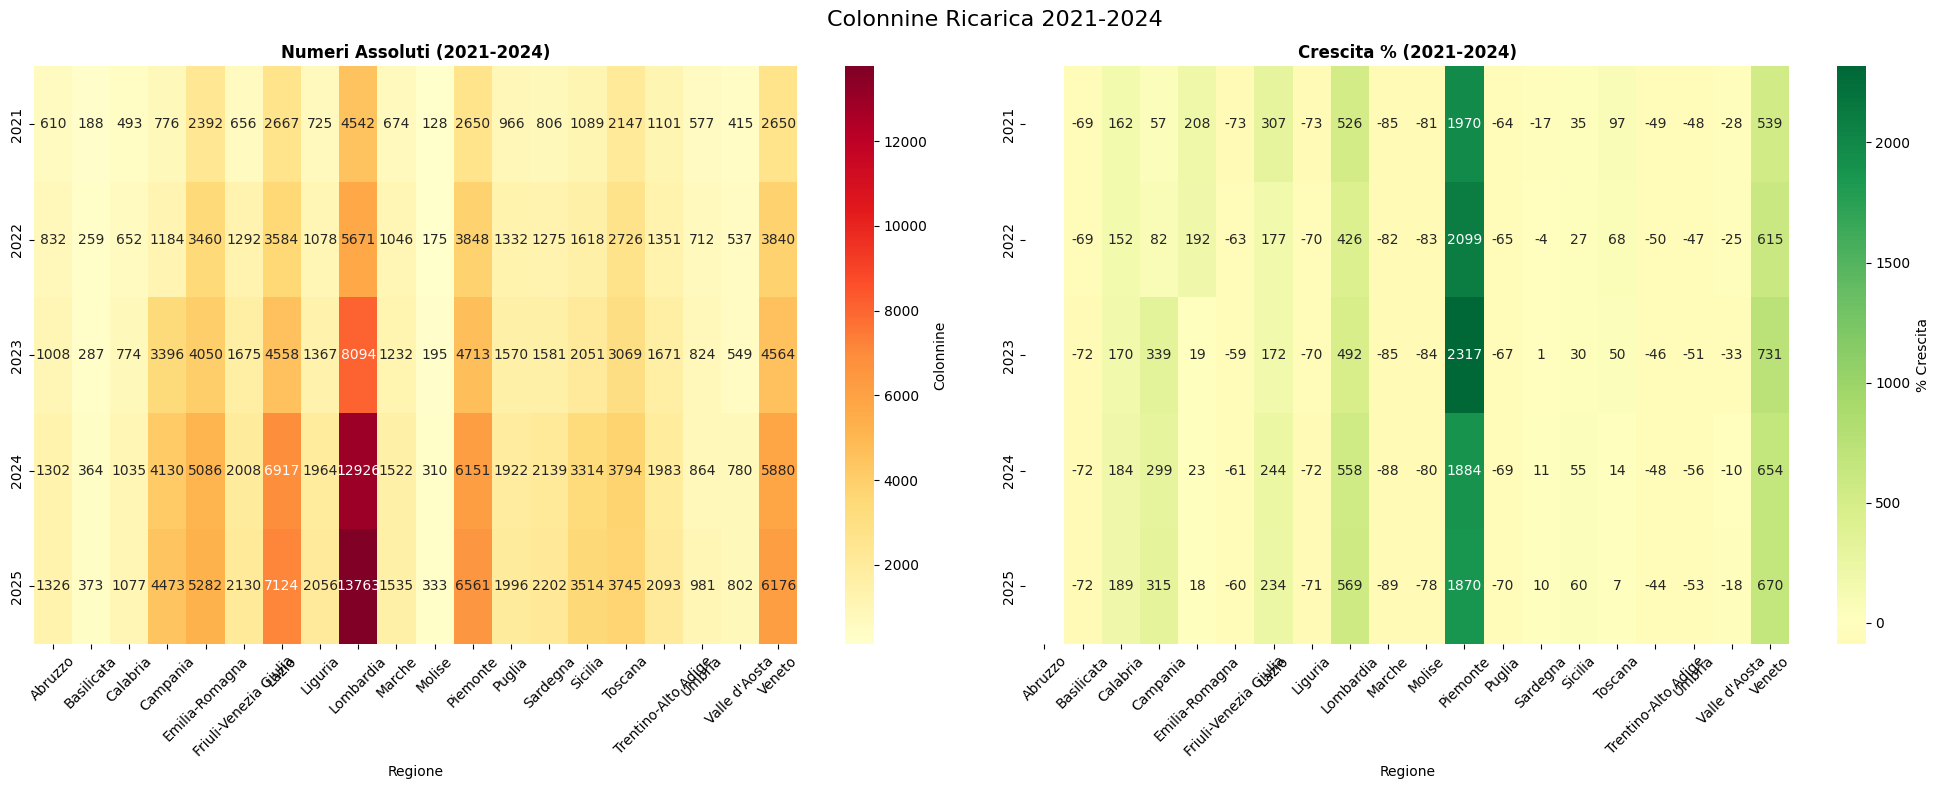

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(df_heatmap, annot=True, fmt='d', cmap='YlOrRd', ax=ax1,
            cbar_kws={'label': 'Colonnine'})
ax1.set_title('Numeri Assoluti (2021-2024)', fontweight='bold')

df_growth = df_heatmap.pct_change(axis=1) * 100
sns.heatmap(df_growth, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax2,
            cbar_kws={'label': '% Crescita'})
ax2.set_title('Crescita % (2021-2024)', fontweight='bold')

plt.suptitle('Colonnine Ricarica 2021-2024', fontsize=16)
for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


/var/folders/tg/8_yg9tkx2179wl4jrjqwhyzm0000gn/T/ipykernel_53377/3504352423.py:18: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tg/8_yg9tkx2179wl4jrjqwhyzm0000gn/T/ipykernel_53377/3504352423.py:19: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('ha6_top_2024.png', dpi=300, bbox_inches='tight')
/Users/marcobellante/Documents/UNIVERSITA'/VISUALIZZAZIONE_SCIENTIFICA/data_visualization/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


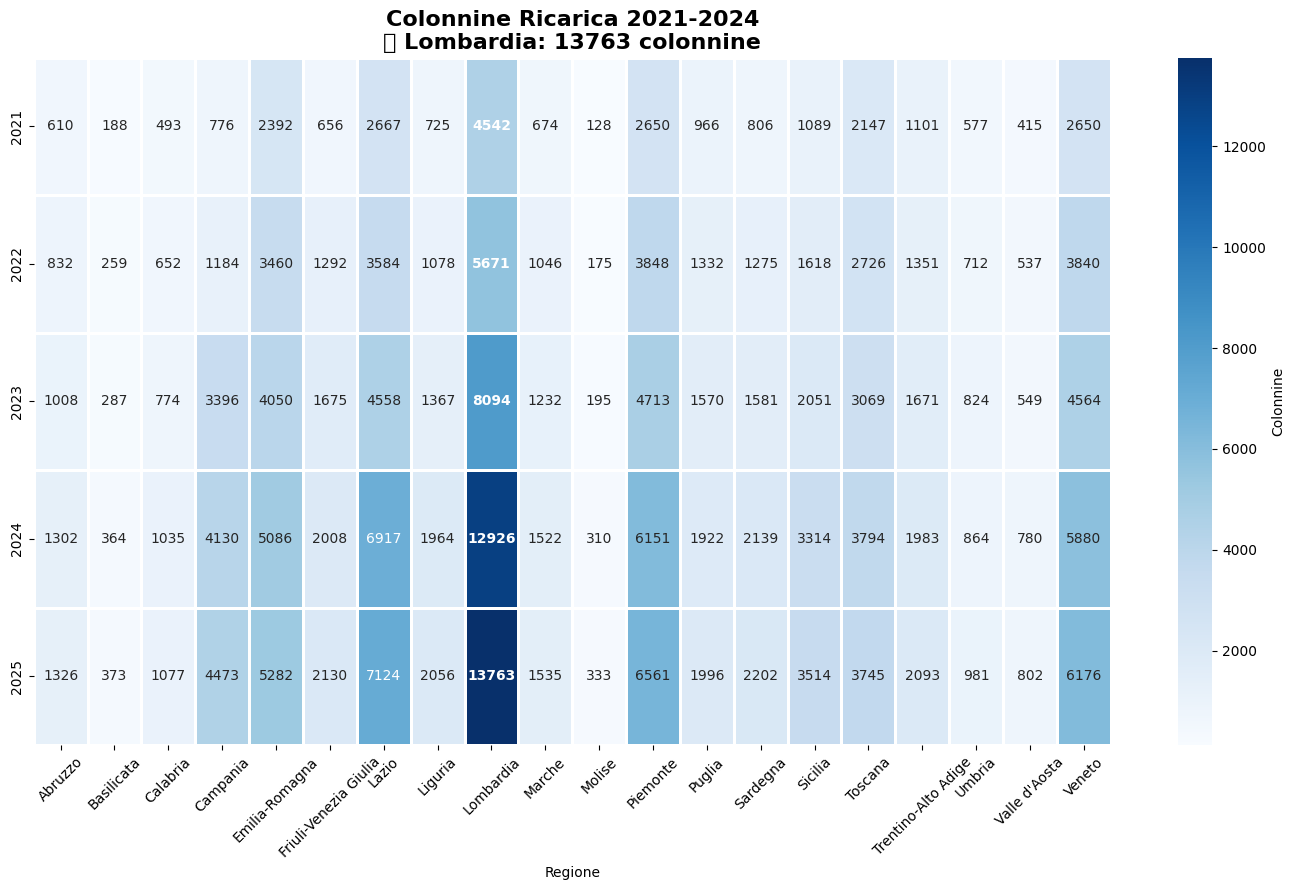

In [ ]:
top_region_2024 = df_heatmap.iloc[-1].idxmax()
top_value_2024 = df_heatmap.iloc[-1].max()

plt.figure(figsize=(14, 9))
im = sns.heatmap(df_heatmap, annot=True, fmt='d', cmap='Blues', linewidths=1,
                 cbar_kws={'label': 'Colonnine'})

# Evidenzia TOP 2024
for i, region in enumerate(df_heatmap.columns):
    if region == top_region_2024:
        for j in range(len(df_heatmap)):
            im.texts[j*len(df_heatmap.columns) + i].set_fontweight('bold')
            im.texts[j*len(df_heatmap.columns) + i].set_color('white')

plt.title(f'Colonnine Ricarica 2021-2024\n{top_region_2024}: {int(top_value_2024)} colonnine', 
          fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


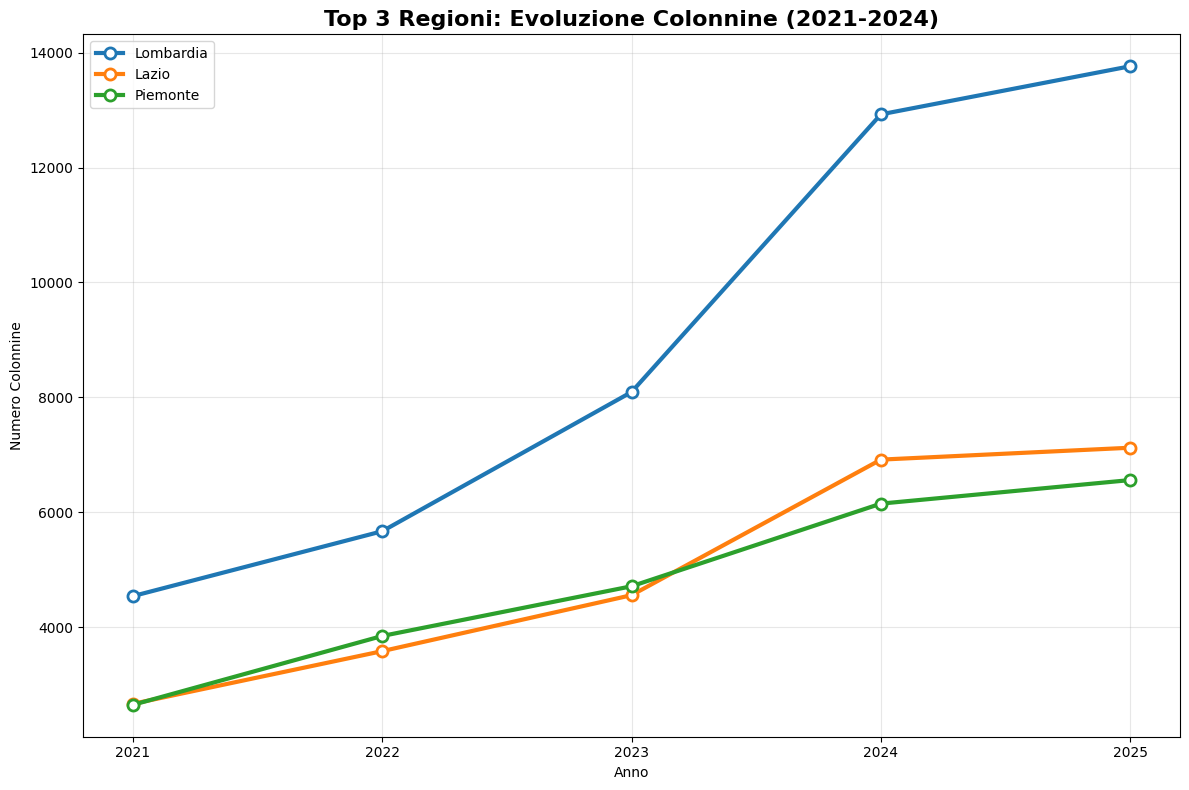

In [ ]:
# TOP 3 REGIONI EVOLUZIONE
top3_2024 = df_heatmap.iloc[-1].nlargest(3).index.tolist()
df_top3 = df_heatmap[top3_2024]

plt.figure(figsize=(12, 8))
for region in top3_2024:
    plt.plot(df_top3.index, df_top3[region], marker='o', linewidth=3, markersize=8, 
             label=region, markerfacecolor='white', markeredgewidth=2)

plt.title('Top 3 Regioni: Evoluzione Colonnine (2021-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Anno')
plt.ylabel('Numero Colonnine')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
